In [ ]:
import torch
print("Torch version:", torch.__version__)
print("GPU available:", torch.cuda.is_available())
print("GPU name:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")

Torch version: 2.11.0+cu128
GPU available: True
GPU name: Tesla T4


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os

# Project folders banana
folders = ['data/train', 'data/val', 'data/test', 'models', 'checkpoints', 'outputs']
for folder in folders:
    os.makedirs(folder, exist_ok=True)

print("✅ Folders are created:")
for folder in folders:
    print(f"  - {folder}")

✅ Folders ban gaye:
  - data/train
  - data/val
  - data/test
  - models
  - checkpoints
  - outputs


In [ ]:
# Setup to download the dataset from Kaggle
!pip install -q kaggle

# You will have to upload the Google APK.
from google.colab import files
print("Upload your Google API (google.json) file:")
uploaded = files.upload()

Apni Kaggle API key (kaggle.json) upload karen:


Saving kaggle (1).json to kaggle (1).json


In [ ]:
import os

# Moving the .json file to the correct folder (with the correct name)
os.makedirs('/root/.kaggle', exist_ok=True)
os.rename('kaggle (1).json', '/root/.kaggle/kaggle.json')

# Permissions set karna
os.chmod('/root/.kaggle/kaggle.json', 600)

print("✅ Kaggle API are set!")

✅ Kaggle API set ho gayi!


In [ ]:
# Downloading the Landscape Dataset (for colorization tasks)
!kaggle datasets download -d arnaud58/landscape-pictures -p data/

# Extracting the zip file
import zipfile
with zipfile.ZipFile('data/landscape-pictures.zip', 'r') as zip_ref:
    zip_ref.extractall('data/raw')

print("✅ Dataset the download and extract the dataset!")

# Let's count how many images there are.
import os
files_count = len(os.listdir('data/raw'))
print(f"Total images: {files_count}")

Dataset URL: https://www.kaggle.com/datasets/arnaud58/landscape-pictures
License(s): CC0-1.0
100% 620M/620M [00:16<00:00, 40.1MB/s]

✅ Dataset download aur extract ho gaya!
Total images: 4319


In [ ]:
# Downloading Face Data Set
!kaggle datasets download -d jessicali9530/celeba-dataset -p data/ --force

import zipfile
with zipfile.ZipFile('data/celeba-dataset.zip', 'r') as zip_ref:
    zip_ref.extractall('data/raw_faces_temp')

print("✅ Face dataset download and extract!")

Dataset URL: https://www.kaggle.com/datasets/jessicali9530/celeba-dataset
License(s): other
100% 1.33G/1.33G [00:33<00:00, 42.3MB/s]

✅ Face dataset download aur extract ho gaya!


In [ ]:
import os
import shutil
import random

random.seed(42)

face_source = None
for root, dirs, files in os.walk('data/raw_faces_temp'):
    if any(f.endswith('.jpg') for f in files):
        face_source = root
        break

print(f"Found the face images here.: {face_source}")

all_face_images = [f for f in os.listdir(face_source) if f.endswith('.jpg')]
selected_faces = random.sample(all_face_images, min(3000, len(all_face_images)))

for img in selected_faces:
    shutil.copy(os.path.join(face_source, img), os.path.join('data/raw', f"face_{img}"))

print(f"✅ {len(selected_faces)} The face images will be added in 'data/raw'.!")
print(f"Total images : {len(os.listdir('data/raw'))}")

Face images mil gayi yahan: data/raw_faces_temp/img_align_celeba/img_align_celeba
✅ 3000 face images 'data/raw' mein add ho gayi!
Total images ab: 7319


In [ ]:
import os
import shutil
import random

random.seed(42)

for folder in ['data/train', 'data/val', 'data/test']:
    shutil.rmtree(folder, ignore_errors=True)
    os.makedirs(folder, exist_ok=True)

source_dir = 'data/raw'
all_images = [f for f in os.listdir(source_dir) if f.endswith(('.jpg', '.jpeg', '.png'))]
random.shuffle(all_images)

total = len(all_images)
train_split = int(0.8 * total)
val_split = int(0.9 * total)

train_images = all_images[:train_split]
val_images = all_images[train_split:val_split]
test_images = all_images[val_split:]

print(f"Total images (landscape + face): {total}")
print(f"Train: {len(train_images)}")
print(f"Validation: {len(val_images)}")
print(f"Test: {len(test_images)}")

def copy_images(image_list, dest_folder):
    for img in image_list:
        shutil.copy(os.path.join(source_dir, img), os.path.join(dest_folder, img))

copy_images(train_images, 'data/train')
copy_images(val_images, 'data/val')
copy_images(test_images, 'data/test')

print("✅ The new combined split (landscape + portrait) is ready!")

Total images (landscape + face): 7319
Train: 5855
Validation: 732
Test: 732
✅ Naya combined split (landscape + face) ho gaya!


In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
from skimage.color import rgb2lab, lab2rgb
import numpy as np
import os

class ColorizationDataset(Dataset):
    def __init__(self, root_dir, image_size=256):
        self.root_dir = root_dir
        self.image_files = [f for f in os.listdir(root_dir) if f.endswith(('.jpg', '.jpeg', '.png'))]
        self.transform = transforms.Compose([
            transforms.Resize((image_size, image_size)),
        ])

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        img_path = os.path.join(self.root_dir, self.image_files[idx])
        img = Image.open(img_path).convert('RGB')
        img = self.transform(img)

        # Converting the PIL image to a NumPy array (0-1 range)
        img_np = np.array(img) / 255.0

        # Converting from RGB to Lab color space
        img_lab = rgb2lab(img_np).astype('float32')

        # Channel: The range is 0–100; we will normalize it to the -1 to 1 range.
        L = img_lab[:, :, 0] / 50.0 - 1.0

        # For channels A and B, the range is -128 to 127; we will normalize this to -1 to 1.
        ab = img_lab[:, :, 1:] / 128.0

        # Converting to PyTorch tensor format (channels, height, width)
        L = torch.from_numpy(L).unsqueeze(0).float()   # shape: (1, H, W)
        ab = torch.from_numpy(ab).permute(2, 0, 1).float()  # shape: (2, H, W)

        return L, ab

print("✅ Dataset class are created!")

✅ Dataset class ban gayi!


In [ ]:
# Conducting a dataset test
train_dataset = ColorizationDataset('data/train', image_size=256)
print(f"Total training images: {len(train_dataset)}")

# Let's check a sample.
L, ab = train_dataset[0]
print(f"L channel shape: {L.shape}")   # Expected: (1, 256, 256)
print(f"ab channels shape: {ab.shape}")  # Expected: (2, 256, 256)
print(f"L range: {L.min().item():.2f} to {L.max().item():.2f}")
print(f"ab range: {ab.min().item():.2f} to {ab.max().item():.2f}")

Total training images: 5855
L channel shape: torch.Size([1, 256, 256])
ab channels shape: torch.Size([2, 256, 256])
L range: -1.00 to 1.00
ab range: -0.72 to 0.47


In [ ]:
from torch.utils.data import DataLoader

# Creating datasets
train_dataset = ColorizationDataset('data/train', image_size=256)
val_dataset = ColorizationDataset('data/val', image_size=256)
test_dataset = ColorizationDataset('data/test', image_size=256)

#  Creating DataLoaders
BATCH_SIZE = 16

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f"✅ DataLoaders are created now!")
print(f"Train batches: {len(train_loader)}")
print(f"Validation batches: {len(val_loader)}")
print(f"Test batches: {len(test_loader)}")

# Let's test a batch.
sample_L, sample_ab = next(iter(train_loader))
print(f"\nBatch shape - L: {sample_L.shape}")   # Expected: (16, 1, 256, 256)
print(f"Batch shape - ab: {sample_ab.shape}")   # Expected: (16, 2, 256, 256)

✅ DataLoaders ban gaye!
Train batches: 366
Validation batches: 46
Test batches: 46

Batch shape - L: torch.Size([16, 1, 256, 256])
Batch shape - ab: torch.Size([16, 2, 256, 256])


In [ ]:
import torch
import torch.nn as nn

# Basic building block: Conv -> BatchNorm -> ReLU
class ConvBlock(nn.Module):
    def __init__(self, in_channels, out_channels, down=True, use_dropout=False):
        super().__init__()
        if down:
            self.conv = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, 4, 2, 1, bias=False, padding_mode='reflect'),
                nn.BatchNorm2d(out_channels),
                nn.LeakyReLU(0.2),
            )
        else:
            self.conv = nn.Sequential(
                nn.ConvTranspose2d(in_channels, out_channels, 4, 2, 1, bias=False),
                nn.BatchNorm2d(out_channels),
                nn.ReLU(),
            )
        self.use_dropout = use_dropout
        self.dropout = nn.Dropout(0.5)

    def forward(self, x):
        x = self.conv(x)
        return self.dropout(x) if self.use_dropout else x


class UNetColorizer(nn.Module):
    """
    U-Net architecture for image colorization.
    Input: L channel (1, 256, 256) - grayscale
    Output: ab channels (2, 256, 256) - predicted color
    """
    def __init__(self, in_channels=1, out_channels=2, features=64):
        super().__init__()

        # ---------- Encoder (downsampling) ----------
        self.initial_down = nn.Sequential(
            nn.Conv2d(in_channels, features, 4, 2, 1, padding_mode='reflect'),
            nn.LeakyReLU(0.2),
        )  # 256 -> 128

        self.down1 = ConvBlock(features, features * 2, down=True)       # 128 -> 64
        self.down2 = ConvBlock(features * 2, features * 4, down=True)   # 64 -> 32
        self.down3 = ConvBlock(features * 4, features * 8, down=True)   # 32 -> 16
        self.down4 = ConvBlock(features * 8, features * 8, down=True)   # 16 -> 8
        self.down5 = ConvBlock(features * 8, features * 8, down=True)   # 8 -> 4
        self.down6 = ConvBlock(features * 8, features * 8, down=True)   # 4 -> 2

        self.bottleneck = nn.Sequential(
            nn.Conv2d(features * 8, features * 8, 4, 2, 1, padding_mode='reflect'),
            nn.ReLU(),
        )  # 2 -> 1

        # ---------- Decoder (upsampling) ----------
        self.up1 = ConvBlock(features * 8, features * 8, down=False, use_dropout=True)
        self.up2 = ConvBlock(features * 8 * 2, features * 8, down=False, use_dropout=True)
        self.up3 = ConvBlock(features * 8 * 2, features * 8, down=False, use_dropout=True)
        self.up4 = ConvBlock(features * 8 * 2, features * 8, down=False)
        self.up5 = ConvBlock(features * 8 * 2, features * 4, down=False)
        self.up6 = ConvBlock(features * 4 * 2, features * 2, down=False)
        self.up7 = ConvBlock(features * 2 * 2, features, down=False)

        self.final_up = nn.Sequential(
            nn.ConvTranspose2d(features * 2, out_channels, 4, 2, 1),
            nn.Tanh(),  # output range: -1 to 1 (matches our normalized ab channels)
        )

    def forward(self, x):
        # Encoder pass (saving outputs for skip connections)
        d1 = self.initial_down(x)
        d2 = self.down1(d1)
        d3 = self.down2(d2)
        d4 = self.down3(d3)
        d5 = self.down4(d4)
        d6 = self.down5(d5)
        d7 = self.down6(d6)
        bottleneck = self.bottleneck(d7)

        # Decoder pass (using skip connections - concatenating encoder outputs)
        up1 = self.up1(bottleneck)
        up2 = self.up2(torch.cat([up1, d7], dim=1))
        up3 = self.up3(torch.cat([up2, d6], dim=1))
        up4 = self.up4(torch.cat([up3, d5], dim=1))
        up5 = self.up5(torch.cat([up4, d4], dim=1))
        up6 = self.up6(torch.cat([up5, d3], dim=1))
        up7 = self.up7(torch.cat([up6, d2], dim=1))

        return self.final_up(torch.cat([up7, d1], dim=1))

print("✅ U-Net model class are created!")

✅ U-Net model class ban gayi!


In [ ]:
# They create models and send them to GPU.
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = UNetColorizer(in_channels=1, out_channels=2).to(device)

# Count the total parameters.
total_params = sum(p.numel() for p in model.parameters())
print(f"✅ Model are ready!")
print(f"Total parameters: {total_params:,}")
print(f"Device: {device}")

# Let's test with a sample input.
sample_input = torch.randn(1, 1, 256, 256).to(device)  # fake grayscale image
output = model(sample_input)
print(f"\nInput shape: {sample_input.shape}")
print(f"Output shape: {output.shape}")  # Expected: (1, 2, 256, 256)

✅ Model ban gaya!
Total parameters: 54,410,434
Device: cuda

Input shape: torch.Size([1, 1, 256, 256])
Output shape: torch.Size([1, 2, 256, 256])


In [ ]:
import torch.optim as optim
from tqdm import tqdm
import time

# ---------- Training Settings ----------
EPOCHS = 40
LEARNING_RATE = 2e-4

# Optimizer aur Loss function
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE, betas=(0.5, 0.999))
criterion = nn.L1Loss()


train_losses = []
val_losses = []

print("✅ The training setup is ready!")
print(f"Epochs: {EPOCHS}")
print(f"Learning rate: {LEARNING_RATE}")
print(f"Loss function: L1 Loss")

✅ Training setup ready hai!
Epochs: 40
Learning rate: 0.0002
Loss function: L1 Loss


In [ ]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    running_loss = 0.0

    for L, ab in tqdm(loader, desc="Training"):
        L, ab = L.to(device), ab.to(device)

        # Forward Pass: Obtaining predictions from the model
        optimizer.zero_grad()
        pred_ab = model(L)

        # calculate the loss (prediction vs asli color)
        loss = criterion(pred_ab, ab)

        # Backward pass: Updating the model
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    return running_loss / len(loader)


def validate_one_epoch(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0

    with torch.no_grad():
        for L, ab in tqdm(loader, desc="Validating"):
            L, ab = L.to(device), ab.to(device)
            pred_ab = model(L)
            loss = criterion(pred_ab, ab)
            running_loss += loss.item()

    return running_loss / len(loader)

print("✅ Training functions are ready!")

✅ Training functions ban gayi!


In [ ]:
import os

CHECKPOINT_DIR = 'checkpoints'
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

best_val_loss = float('inf')

print("🚀 Training is starting...\n")

for epoch in range(EPOCHS):
    start_time = time.time()

    # Training a 1 epoch
    train_loss = train_one_epoch(model, train_loader, optimizer, criterion, device)
    train_losses.append(train_loss)

    # Validation to do
    val_loss = validate_one_epoch(model, val_loader, criterion, device)
    val_losses.append(val_loss)

    epoch_time = time.time() - start_time

    print(f"Epoch [{epoch+1}/{EPOCHS}] | "
          f"Train Loss: {train_loss:.4f} | "
          f"Val Loss: {val_loss:.4f} | "
          f"Time: {epoch_time:.1f}s")

    # Selecting the best model (when loss is minimized)
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), os.path.join(CHECKPOINT_DIR, 'best_model.pth'))
        print(f"  💾 Best model saved! (val_loss: {val_loss:.4f})")

    # Set a checkpoint every 5 epochs.
    if (epoch + 1) % 5 == 0:
        torch.save(model.state_dict(), os.path.join(CHECKPOINT_DIR, f'model_epoch_{epoch+1}.pth'))

print("\n✅ Training complete!")

🚀 Training shuru ho rahi hai...



Validating: 100%|██████████| 46/46 [00:11<00:00,  4.09it/s]


Epoch [1/40] | Train Loss: 0.1110 | Val Loss: 0.0848 | Time: 125.5s
  💾 Best model saved! (val_loss: 0.0848)


Validating: 100%|██████████| 46/46 [00:12<00:00,  3.75it/s]


Epoch [2/40] | Train Loss: 0.0811 | Val Loss: 0.0782 | Time: 129.2s
  💾 Best model saved! (val_loss: 0.0782)


...

Epoch [38/40] | Train Loss: 0.0433 | Val Loss: 0.0648 | Time: 126.2s


Validating: 100%|██████████| 46/46 [00:11<00:00,  3.89it/s]


Epoch [39/40] | Train Loss: 0.0425 | Val Loss: 0.0658 | Time: 128.6s


Validating: 100%|██████████| 46/46 [00:12<00:00,  3.83it/s]


Epoch [40/40] | Train Loss: 0.0421 | Val Loss: 0.0667 | Time: 127.1s

✅ Training complete!


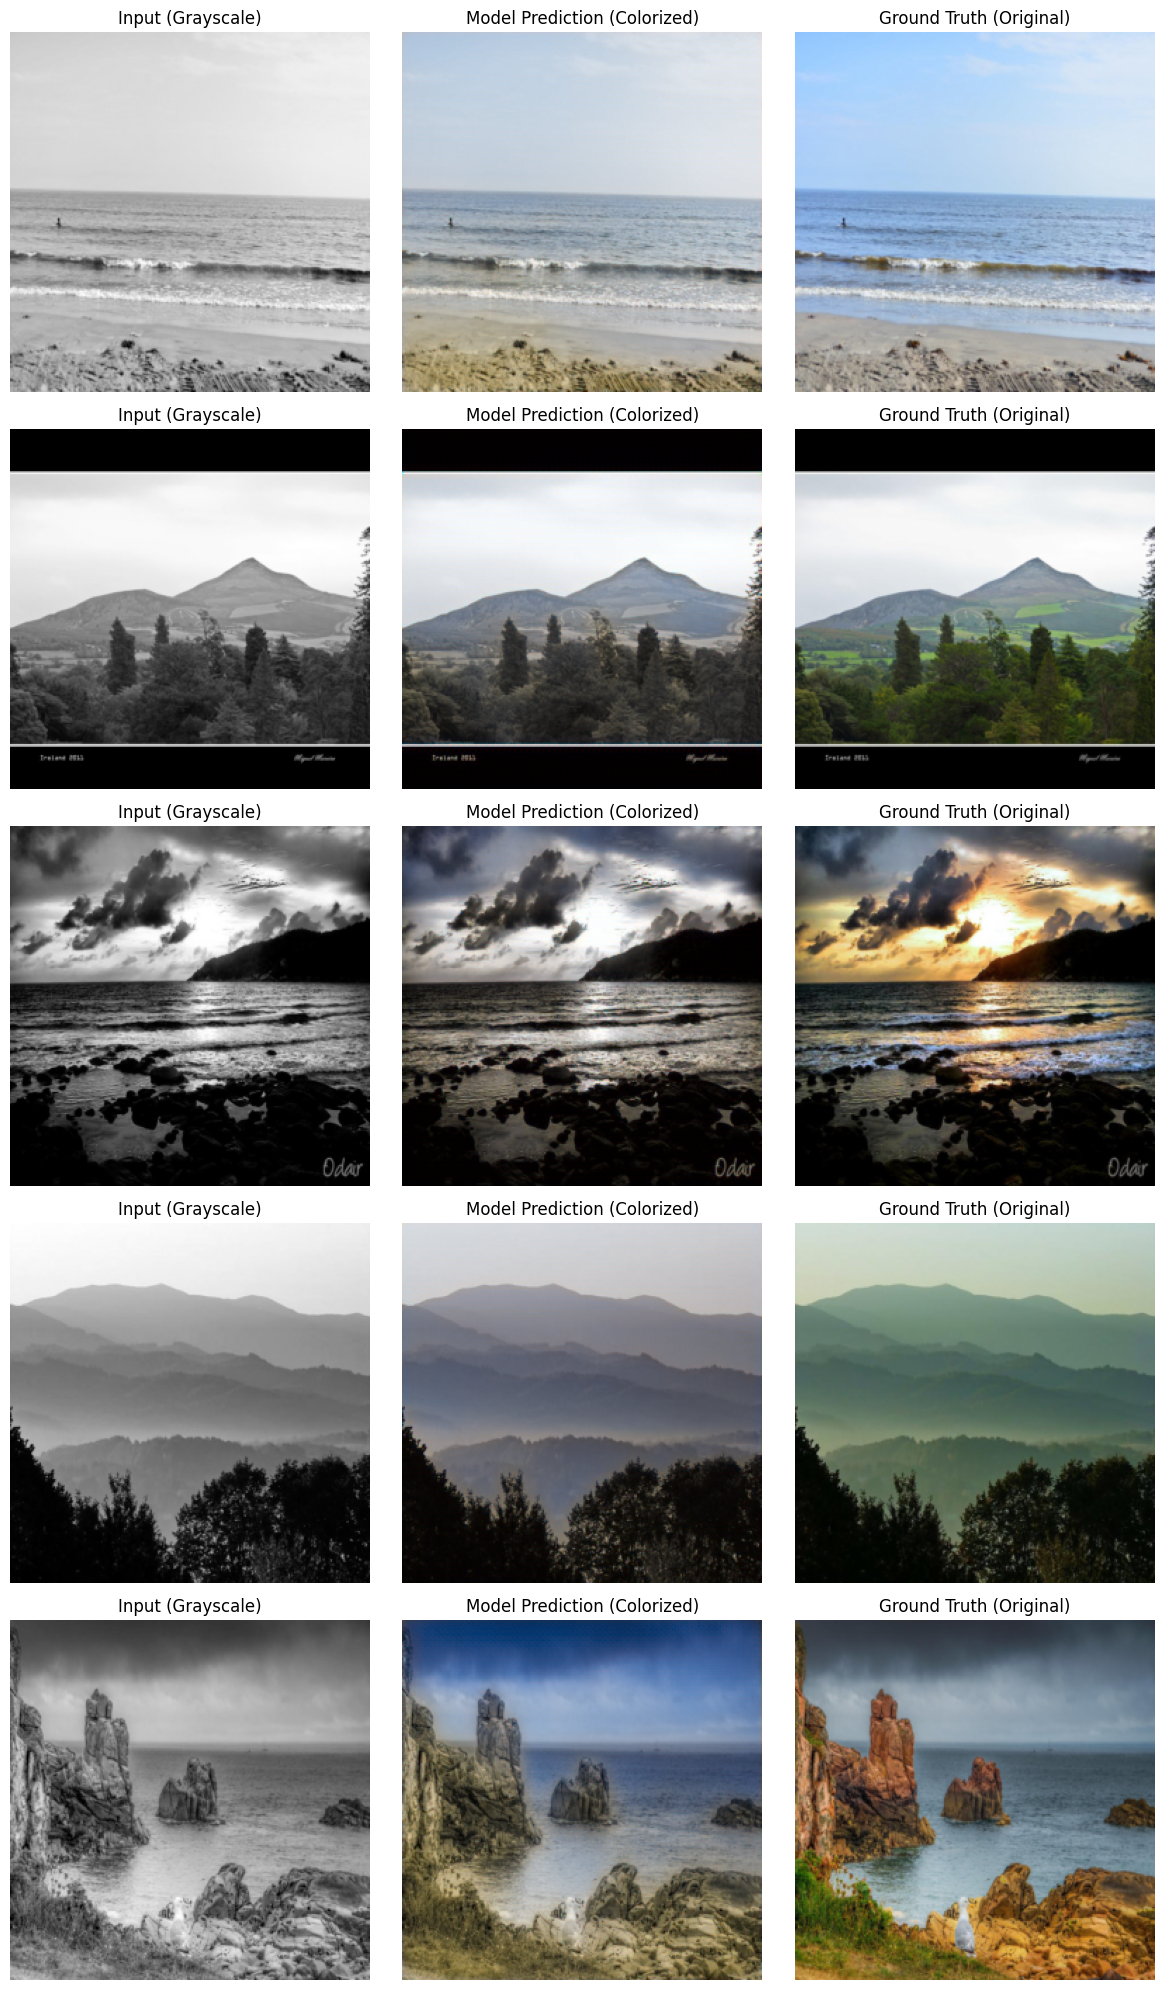

✅ Results save ho gaye outputs/sample_results.png mein!


In [ ]:
import matplotlib.pyplot as plt
from skimage.color import lab2rgb
import numpy as np

def lab_to_rgb(L, ab):
    """
    It normalizes the data and then converts the tensors back into RGB images.
    """
    L = L * 50.0 + 50.0          # wapas 0-100 range mein
    ab = ab * 128.0              # wapas -128 to 127 range mein
    Lab = torch.cat([L, ab], dim=0).permute(1, 2, 0).cpu().numpy()
    rgb = lab2rgb(Lab.astype(np.float64))
    return rgb

# Loading the best model
model.load_state_dict(torch.load('checkpoints/best_model.pth'))
model.eval()

# Let's take some images from the test set
num_samples = 5
fig, axes = plt.subplots(num_samples, 3, figsize=(12, 4 * num_samples))

with torch.no_grad():
    for i in range(num_samples):
        L, ab_true = test_dataset[i]
        L_input = L.unsqueeze(0).to(device)  # batch dimension add karna

        # take prediction to the model
        ab_pred = model(L_input).squeeze(0).cpu()

        # Three images are generated: grayscale, the model's prediction, and the original.
        gray_img = (L.squeeze(0).numpy() + 1) / 2  # 0-1 range mein
        pred_rgb = lab_to_rgb(L, ab_pred)
        true_rgb = lab_to_rgb(L, ab_true)

        axes[i, 0].imshow(gray_img, cmap='gray')
        axes[i, 0].set_title('Input (Grayscale)')
        axes[i, 0].axis('off')

        axes[i, 1].imshow(pred_rgb)
        axes[i, 1].set_title('Model Prediction (Colorized)')
        axes[i, 1].axis('off')

        axes[i, 2].imshow(true_rgb)
        axes[i, 2].set_title('Ground Truth (Original)')
        axes[i, 2].axis('off')

plt.tight_layout()
plt.savefig('outputs/sample_results.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Results saved to outputs/sample_results.png.!")

In [ ]:
!pip install -q gradio

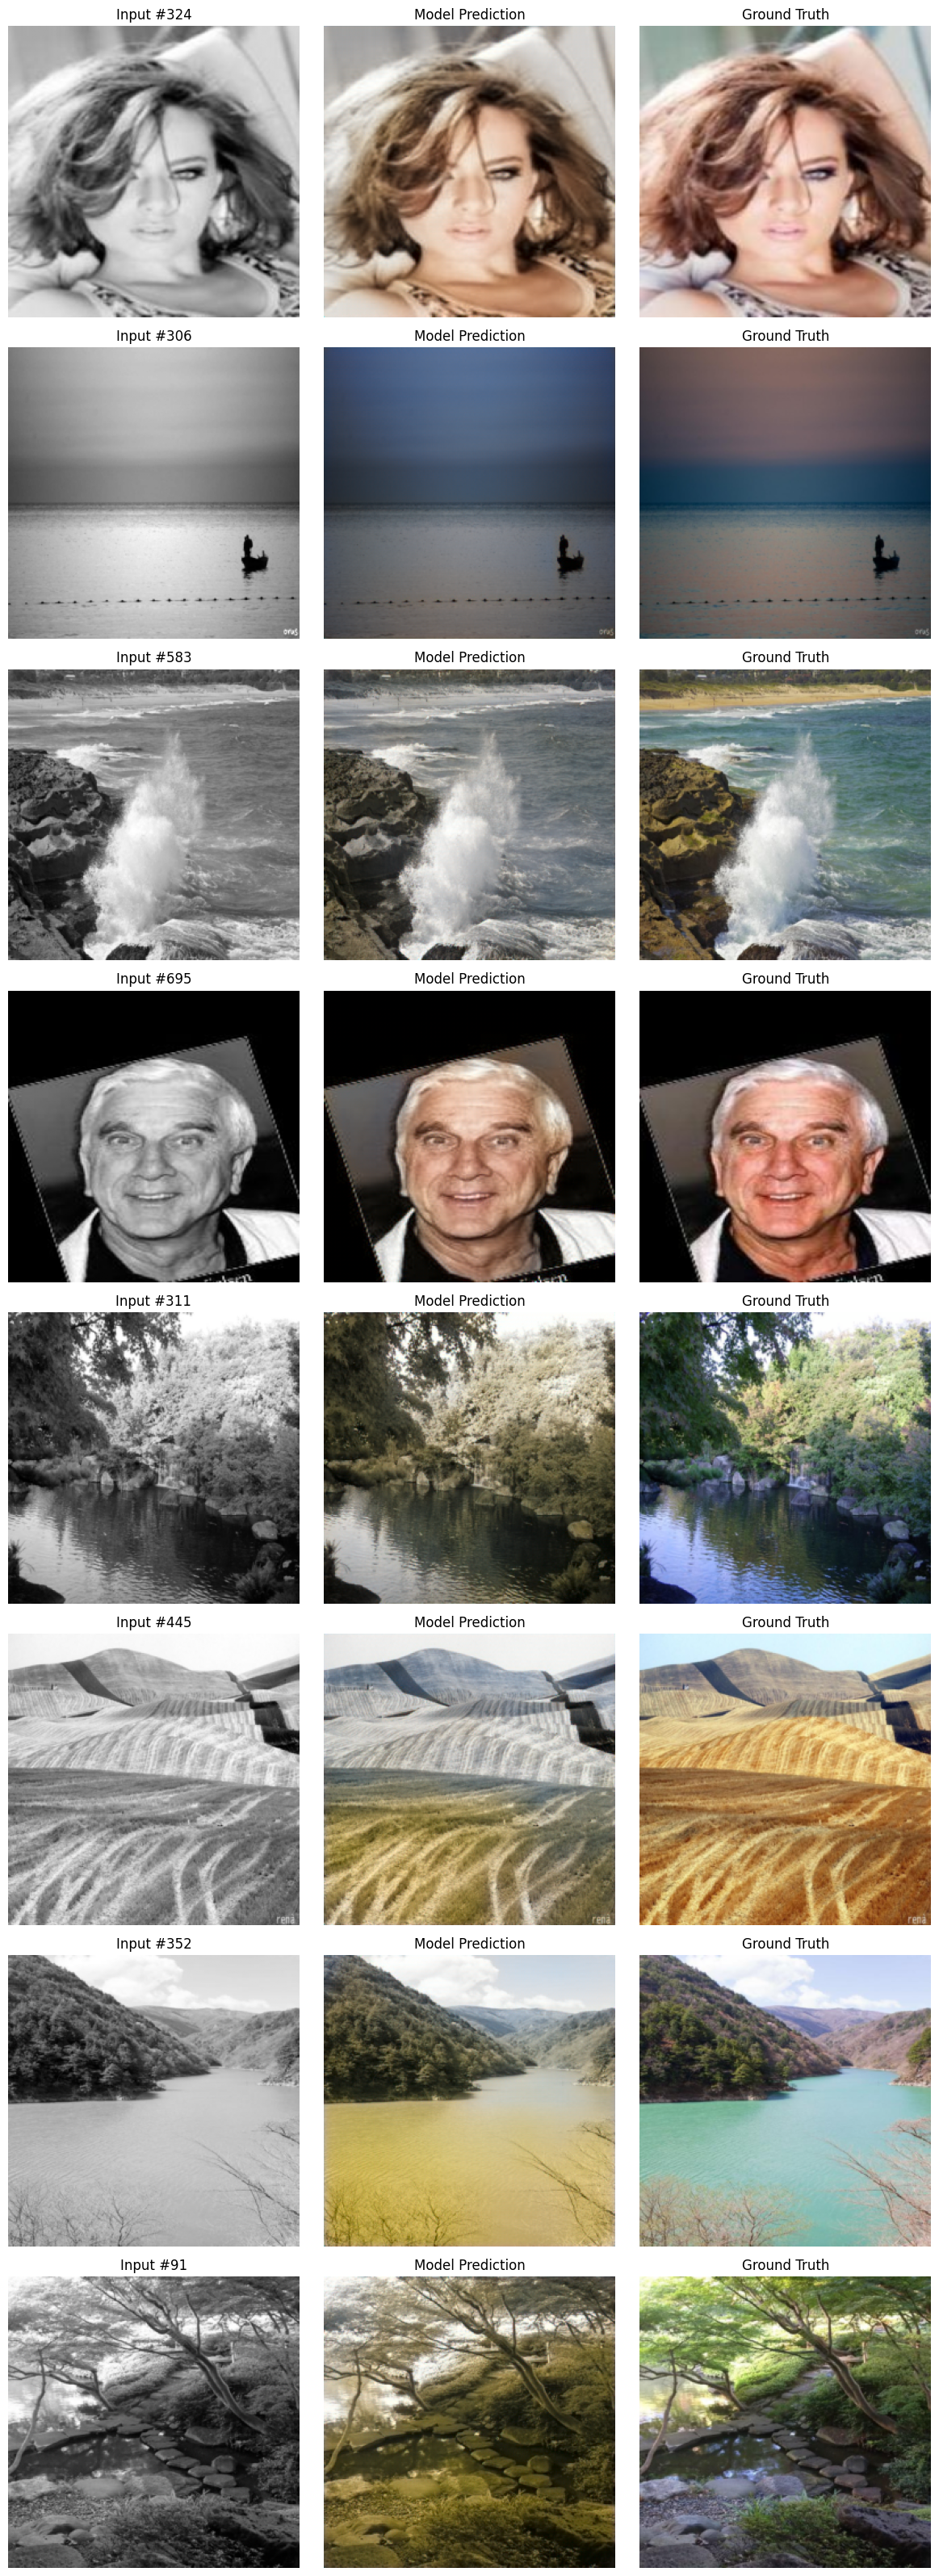

✅ Landscape + Face model ke results!


In [ ]:
import matplotlib.pyplot as plt
import random
import numpy as np
from skimage.color import lab2rgb

def lab_to_rgb(L, ab):
    """
     It normalizes the data and then converts the tensors back into RGB images
    """
    L = L * 50.0 + 50.0
    ab = ab * 128.0
    Lab = torch.cat([L, ab], dim=0).permute(1, 2, 0).cpu().numpy()
    rgb = lab2rgb(Lab.astype(np.float64))
    return rgb

#  Loading the best model
model.load_state_dict(torch.load('checkpoints/best_model.pth'))
model.eval()

# We take mixed samples from the test set (both landscape and face).
num_samples = 8
random_indices = random.sample(range(len(test_dataset)), num_samples)

fig, axes = plt.subplots(num_samples, 3, figsize=(12, 4 * num_samples))

with torch.no_grad():
    for i, idx in enumerate(random_indices):
        L, ab_true = test_dataset[idx]
        L_input = L.unsqueeze(0).to(device)

        ab_pred = model(L_input).squeeze(0).cpu()

        gray_img = (L.squeeze(0).numpy() + 1) / 2
        pred_rgb = lab_to_rgb(L, ab_pred)
        true_rgb = lab_to_rgb(L, ab_true)

        axes[i, 0].imshow(gray_img, cmap='gray')
        axes[i, 0].set_title(f'Input #{idx}')
        axes[i, 0].axis('off')

        axes[i, 1].imshow(pred_rgb)
        axes[i, 1].set_title('Model Prediction')
        axes[i, 1].axis('off')

        axes[i, 2].imshow(true_rgb)
        axes[i, 2].set_title('Ground Truth')
        axes[i, 2].axis('off')

plt.tight_layout()
plt.savefig('outputs/combined_model_results.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Results of the Landscape + Face Model!")

In [3]:
import gradio as gr
from PIL import Image
import numpy as np
import torch
import torch.nn as nn
from skimage.color import rgb2lab, lab2rgb

# Loading the best (new, landscape + face) model
model.load_state_dict(torch.load('checkpoints/best_model.pth'))
model.eval()

def lab_to_rgb(L, ab):
    L = L * 50.0 + 50.0
    ab = ab * 128.0
    Lab = torch.cat([L, ab], dim=0).permute(1, 2, 0).cpu().numpy()
    rgb = lab2rgb(Lab.astype(np.float64))
    return rgb

def colorize_image(input_image):
    if input_image is None:
        return None

    img = input_image.convert('RGB')
    original_size = img.size

    img_resized = img.resize((256, 256))
    img_np = np.array(img_resized) / 255.0

    img_lab = rgb2lab(img_np).astype('float32')
    L = img_lab[:, :, 0] / 50.0 - 1.0
    L_tensor = torch.from_numpy(L).unsqueeze(0).unsqueeze(0).float().to(device)

    with torch.no_grad():
        ab_pred = model(L_tensor).squeeze(0).cpu()

    L_for_convert = torch.from_numpy(L).unsqueeze(0)
    result_rgb = lab_to_rgb(L_for_convert, ab_pred)

    result_img = Image.fromarray((result_rgb * 255).astype(np.uint8))
    result_img = result_img.resize(original_size)

    return result_img

demo = gr.Interface(
    fn=colorize_image,
    inputs=gr.Image(type="pil", label="Upload the Black & White Image"),
    outputs=gr.Image(type="pil", label="Colorized Result"),
    title="🎨 AI Image Colorization (Landscape + Portrait)",
    description=" Upload the any black & white image (landscape or face/portrait) , AI model give the color automatically. Built using U-Net architecture (PyTorch)., It has been trained on both landscape and face images.",
    theme=gr.themes.Soft()
)

demo.launch(share=True, debug=True)

NameError: name 'model' is not defined